## Basic Ridge Regression Implementation
### Key Components
#### Data Generation

* Creates synthetic regression data
* Single feature with added noise

In [110]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [111]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=7)

### Visualization

* Plots the generated data points
* Shows linear relationship with noise

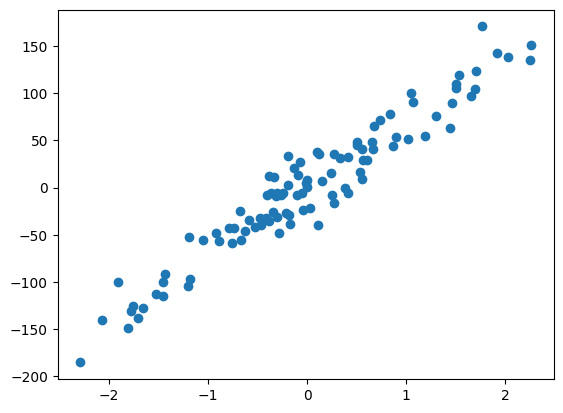

In [112]:
plt.scatter(X,y)

In [113]:
from sklearn.model_selection import train_test_split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 18)

## Model Comparison
### 1.Linear Regression

* Standard linear regression
* Achieves R² score of ~0.97

In [115]:
from sklearn.linear_model import LinearRegression, Ridge

In [116]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [117]:
y_pred =lr.predict(X_test)

In [118]:
lr.coef_

array([67.65712361])

In [119]:
lr.intercept_

np.float64(0.4169717039675749)

In [120]:
from sklearn.metrics import r2_score

In [121]:
r2_score(y_pred, y_test)

0.9723206505704729

### 2.Ridge Regression

* Ridge regression with alpha=10
* Achieves R² score of ~0.95

In [122]:
rg = Ridge(10)

In [123]:
rg.fit(X_train, y_train)

Ridge(alpha=10)

In [124]:
y_pred1 = rg.predict(X_test)

In [125]:
r2_score(y_test, y_pred1)

0.9513242693369623

### Custom Implementation

* Simplified implementation for single feature
* Explicit calculation of slope (m) and intercept (b)
* Includes regularization in denominator
* Matches scikit-learn's performance (R² ~0.95)

In [145]:
class Ridge:
    def __init__(self, alpha):
        self.m = None
        self.b = None
        self.alpha = alpha

    def fit(self, X_train, y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + (X_train[i] - X_train.mean())**2

        self.m = num/(den + self.alpha)
        self.b= y_train.mean() - self.m * X_train.mean()

    def predict(self, X_test):
        return (self.m * X_test) + self.b

In [146]:
ridge = Ridge(10)

In [147]:
ridge.fit(X_train, y_train)

In [148]:
ridge.m.shape

(1,)

In [149]:
ridge.b.shape

(1,)

In [150]:
y_pred2 = ridge.predict(X_test)

In [151]:
r2_score(y_test, y_pred2)

0.9513242693369621